In [16]:
# CELL 1: Import libraries
import pandas as pd
import numpy as np
import psycopg2
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

print(f'✅ Libraries loaded')

✅ Libraries loaded


In [17]:
# CELL 2: Connect to PostgreSQL
conn = psycopg2.connect(
    host='localhost',
    port=5432,
    database='aviation_cost_db',
    user='postgres',
    password=os.environ.get('AVIATION_DB_PASSWORD', '')
)

print('✅ Connected to aviation_cost_db')

✅ Connected to aviation_cost_db


In [18]:
# CELL 3: Load OTP Events
otp_events = pd.read_sql('SELECT * FROM otp_events', conn)
print(f'✅ OTP Events: {len(otp_events)} rows')


✅ OTP Events: 4837 rows


C:\Users\ericm\AppData\Local\Temp\ipykernel_45172\1845568078.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  otp_events = pd.read_sql('SELECT * FROM otp_events', conn)


In [19]:
# CELL 4: Load Delay Causes
delay_causes = pd.read_sql('SELECT * FROM delay_causes', conn)
print(f'✅ Delay Causes: {len(delay_causes)} rows')


# Show unique causes
causes_summary = delay_causes[['cause_code', 'cause_name', 'proportion_of_delays']].drop_duplicates().sort_values('proportion_of_delays', ascending=False)
print('\nDelay Attribution (% of all delays):')
print(causes_summary)


✅ Delay Causes: 45 rows

Delay Attribution (% of all delays):
  cause_code           cause_name  proportion_of_delays
0         RC          Reactionary                  0.46
1         AL   Airline Operations                  0.27
2         AT  Air Traffic Control                  0.14
3         WX              Weather                  0.07
4         AP   Airport Operations                  0.06


C:\Users\ericm\AppData\Local\Temp\ipykernel_45172\4142270493.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  delay_causes = pd.read_sql('SELECT * FROM delay_causes', conn)


In [20]:
# CELL 5: Load Aircraft Types
aircraft_types = pd.read_sql('SELECT * FROM aircraft_types', conn)
print(f'✅ Aircraft Types: {len(aircraft_types)} rows')

print('\nAircraft with fuel burn data:')
print(aircraft_types[['aircraft_code', 'aircraft_name', 'fuel_burn_litres_ph', 'seats', 'aircraft_tier']])


✅ Aircraft Types: 8 rows

Aircraft with fuel burn data:
  aircraft_code              aircraft_name  fuel_burn_litres_ph  seats  \
0          B738             Boeing 737-800               2650.0    174   
1          A320            Airbus A320-200               2520.0    180   
2          B717             Boeing 717-200               1980.0    110   
3          DH8Q   De Havilland Dash 8-Q400               1100.0     78   
4          ATR7             ATR 72-500/600                850.0     68   
5          SB34                  Saab 340B                520.0     34   
6          DH81    De Havilland Dash 8-100                580.0     36   
7          C208  Cessna 208B Grand Caravan                180.0     12   

   aircraft_tier  
0       mainline  
1       mainline  
2   regional_jet  
3  regional_prop  
4  regional_prop  
5    remote_prop  
6    remote_prop  
7    remote_prop  


C:\Users\ericm\AppData\Local\Temp\ipykernel_45172\767440205.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  aircraft_types = pd.read_sql('SELECT * FROM aircraft_types', conn)


In [21]:
# CELL 6: Load Airline Fleet and Fuel Prices
airline_fleet = pd.read_sql('SELECT * FROM airline_fleet', conn)
print(f'✅ Airline Fleet: {len(airline_fleet)} rows')

fuel_prices = pd.read_sql('SELECT * FROM fuel_prices', conn)
print(f'✅ Fuel Prices: {len(fuel_prices)} rows')

fuel_prices_summary = fuel_prices[['year', 'aud_per_litre']].drop_duplicates().sort_values('year')
print('\nFuel price by year (AUD per litre):')
print(fuel_prices_summary)

conn.close()
print('\n✅ PostgreSQL connection closed')


✅ Airline Fleet: 26 rows
✅ Fuel Prices: 9 rows

Fuel price by year (AUD per litre):
   year  aud_per_litre
0  2023           1.11
1  2024           1.03
2  2025           1.00

✅ PostgreSQL connection closed


C:\Users\ericm\AppData\Local\Temp\ipykernel_45172\1447196040.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  airline_fleet = pd.read_sql('SELECT * FROM airline_fleet', conn)
C:\Users\ericm\AppData\Local\Temp\ipykernel_45172\1447196040.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fuel_prices = pd.read_sql('SELECT * FROM fuel_prices', conn)


In [22]:
# CELL 7: Define Fuel Burn Model
# Fuel burn rates by phase (kg/min) - EUROCONTROL BADA
fuel_burn_rates = {
    'taxi': 11.7,              # Ground taxi (engine running)
    'arrival_mgmt': 35.2,      # Holding/arrival management (airborne)
    'enroute': 40.1,           # Cruise flight
    'speed_recovery': 44.1     # 10% penalty on en-route (40.1 * 1.1)
}

# Map delay causes to flight phases
cause_to_phase = {
    'RC': {'phase': 'taxi', 'description': 'Reactionary → ground hold + taxi'},
    'AL': {'phase': 'taxi', 'description': 'Airline Ops → ground turnaround'},
    'AT': {'phase': 'arrival_mgmt', 'description': 'ATC → airborne holding'},
    'WX': {'phase': 'enroute', 'description': 'Weather → en-route extension'},
    'AP': {'phase': 'taxi', 'description': 'Airport Ops → ground hold'},
    'DD': {'phase': 'speed_recovery', 'description': 'Speed Recovery → higher cruise Mach'}
}

print("DELAY CAUSE → FLIGHT PHASE → FUEL BURN RATE MAPPING\n")
print("-" * 80)
for code, details in cause_to_phase.items():
    phase = details['phase']
    rate = fuel_burn_rates[phase]
    desc = details['description']
    print(f"{code:4s} | {desc:40s} | {rate:5.1f} kg/min")



DELAY CAUSE → FLIGHT PHASE → FUEL BURN RATE MAPPING

--------------------------------------------------------------------------------
RC   | Reactionary → ground hold + taxi         |  11.7 kg/min
AL   | Airline Ops → ground turnaround          |  11.7 kg/min
AT   | ATC → airborne holding                   |  35.2 kg/min
WX   | Weather → en-route extension             |  40.1 kg/min
AP   | Airport Ops → ground hold                |  11.7 kg/min
DD   | Speed Recovery → higher cruise Mach      |  44.1 kg/min


In [23]:
# CELL 8: Prepare Delay Data by Cause
# Create delay causes lookup (proportions by year)
causes_lookup = delay_causes[['year', 'cause_code', 'proportion_of_delays']].drop_duplicates()
causes_lookup = causes_lookup.rename(columns={'proportion_of_delays': 'delay_proportion'})

# Sum departures delayed by airline and year
departures_delayed = otp_events.groupby(['airline', 'year'])['departures_delayed'].sum().reset_index()
departures_delayed = departures_delayed.rename(columns={'departures_delayed': 'total_departures_delayed'})

# Sum arrivals delayed by airline and year
arrivals_delayed = otp_events.groupby(['airline', 'year'])['arrivals_delayed'].sum().reset_index()
arrivals_delayed = arrivals_delayed.rename(columns={'arrivals_delayed': 'total_arrivals_delayed'})

# Merge
analysis = departures_delayed.merge(arrivals_delayed, on=['airline', 'year'], how='outer').fillna(0)

print("Delay summary by airline and year:")
print(analysis)


Delay summary by airline and year:
                               airline     year  total_departures_delayed  \
0                         All Airlines     2018                    193374   
1                         All Airlines     2019                    205439   
2                         All Airlines     2022                    273458   
3                         All Airlines  2022-23                    281995   
4                         All Airlines     2023                    276945   
..                                 ...      ...                       ...   
73  Virgin Australia Regional Airlines     2023                      3381   
74  Virgin Australia Regional Airlines  2023-24                      2654   
75  Virgin Australia Regional Airlines     2024                      2639   
76  Virgin Australia Regional Airlines  2024-25                      2141   
77  Virgin Australia Regional Airlines     2025                      1371   

    total_arrivals_delayed  
0          

In [30]:
# CELL 9: Distribute Delays by Cause
# For each airline/year, multiply total departures_delayed by each cause proportion
analysis_expanded = []

for idx, row in analysis.iterrows():
    airline = row['airline']
    year = row['year']
    total_delays = row['total_departures_delayed']
    
    # Get causes for this year
    year_causes = causes_lookup[causes_lookup['year'] == year]
    
    # Distribute total delays by cause
    for _, cause_row in year_causes.iterrows():
        cause = cause_row['cause_code']
        proportion = cause_row['delay_proportion']
        
        delays_by_cause = total_delays * proportion
        
        analysis_expanded.append({
            'airline': airline,
            'year': year,
            'cause_code': cause,
            'total_delays_for_cause': delays_by_cause,
            'delay_proportion': proportion
        })

analysis_by_cause = pd.DataFrame(analysis_expanded)

print("Delays distributed by cause (sample):")
print(analysis_by_cause.head(10))


Delays distributed by cause (sample):
        airline  year cause_code  total_delays_for_cause  delay_proportion
0  All Airlines  2023         RC               127394.70              0.46
1  All Airlines  2023         AL                74775.15              0.27
2  All Airlines  2023         AT                38772.30              0.14
3  All Airlines  2023         WX                19386.15              0.07
4  All Airlines  2023         AP                16616.70              0.06
5  All Airlines  2023         RC               119241.20              0.46
6  All Airlines  2023         AL                69989.40              0.27
7  All Airlines  2023         AT                36290.80              0.14
8  All Airlines  2023         WX                18145.40              0.07
9  All Airlines  2023         AP                15553.20              0.06


In [29]:
# Clean year column - convert all to just the year number
def clean_year(year_val):
    """Convert year formats like '2023-24' to 2023"""
    year_str = str(year_val)
    # Take first 4 characters (the year)
    return int(year_str[:4])

# Apply to both dataframes
analysis['year'] = analysis['year'].apply(clean_year)

# Filter to only 2023, 2024, 2025 (where we have delay cause data)
analysis = analysis[analysis['year'].isin([2023, 2024, 2025])].copy()

print("Cleaned analysis:")
print(analysis)
print(f"\nYears available: {analysis['year'].unique()}")

Cleaned analysis:
                               airline  year  total_departures_delayed  \
4                         All Airlines  2023                    276945   
5                         All Airlines  2023                    259220   
6                         All Airlines  2024                    241462   
7                         All Airlines  2024                    223043   
8                         All Airlines  2025                    215193   
9                                Bonza  2023                       485   
10                               Bonza  2023                      1088   
11                               Bonza  2024                       603   
12                          Hinterland  2023                       411   
13                          Hinterland  2024                       907   
14                          Hinterland  2024                      1262   
15                          Hinterland  2025                      1367   
20                  

In [31]:
# CELL 10: Calculate Fuel Burn in Kilograms
 
# Add flight phase and fuel burn rate
def get_phase_and_rate(cause_code):
    """Return flight phase and fuel burn rate for a cause"""
    mapping = cause_to_phase.get(cause_code, {'phase': 'taxi'})
    phase = mapping['phase']
    rate = fuel_burn_rates[phase]
    return phase, rate
 
# Apply to each row
analysis_by_cause[['flight_phase', 'fuel_burn_rate_kg_per_min']] = analysis_by_cause['cause_code'].apply(
    lambda x: pd.Series(get_phase_and_rate(x))
)
 
# Calculate fuel burn
# Assumption: Each delayed flight is delayed 30 minutes on average
DELAY_MINUTES_AVERAGE = 30
 
analysis_by_cause['delay_minutes_total'] = analysis_by_cause['total_delays_for_cause'] * DELAY_MINUTES_AVERAGE
analysis_by_cause['fuel_burn_kg'] = analysis_by_cause['delay_minutes_total'] * analysis_by_cause['fuel_burn_rate_kg_per_min']
 
# Convert kg to liters (density of Jet A-1 ≈ 0.8 kg/L)
analysis_by_cause['fuel_burn_litres'] = analysis_by_cause['fuel_burn_kg'] / 0.8
 
print("Fuel burn calculation by delay cause (sample):")
print(analysis_by_cause[['airline', 'year', 'cause_code', 'flight_phase', 'total_delays_for_cause', 
                          'delay_minutes_total', 'fuel_burn_kg', 'fuel_burn_litres']].head(10))
 

Fuel burn calculation by delay cause (sample):
        airline  year cause_code  flight_phase  total_delays_for_cause  \
0  All Airlines  2023         RC          taxi               127394.70   
1  All Airlines  2023         AL          taxi                74775.15   
2  All Airlines  2023         AT  arrival_mgmt                38772.30   
3  All Airlines  2023         WX       enroute                19386.15   
4  All Airlines  2023         AP          taxi                16616.70   
5  All Airlines  2023         RC          taxi               119241.20   
6  All Airlines  2023         AL          taxi                69989.40   
7  All Airlines  2023         AT  arrival_mgmt                36290.80   
8  All Airlines  2023         WX       enroute                18145.40   
9  All Airlines  2023         AP          taxi                15553.20   

   delay_minutes_total  fuel_burn_kg  fuel_burn_litres  
0            3821841.0   44715539.70      5.589442e+07  
1            2243254.5  

In [32]:
# CELL 11: Calculate Fuel Cost in AUD
# ============================================================================
 
# Add fuel prices
fuel_price_lookup = fuel_prices[['year', 'aud_per_litre']].drop_duplicates()
 
analysis_by_cause = analysis_by_cause.merge(fuel_price_lookup, on='year', how='left')
 
# Calculate cost
analysis_by_cause['fuel_cost_aud'] = analysis_by_cause['fuel_burn_litres'] * analysis_by_cause['aud_per_litre']
 
print("Fuel burn cost by delay cause (sample):")
print(analysis_by_cause[['airline', 'year', 'cause_code', 'fuel_burn_litres', 
                          'aud_per_litre', 'fuel_cost_aud']].head(10))
 
print(f"\n✅ Fuel burn impact calculated for {len(analysis_by_cause)} delay cause scenarios")

Fuel burn cost by delay cause (sample):
        airline  year cause_code  fuel_burn_litres  aud_per_litre  \
0  All Airlines  2023         RC      5.589442e+07           1.11   
1  All Airlines  2023         AL      3.280760e+07           1.11   
2  All Airlines  2023         AT      5.117944e+07           1.11   
3  All Airlines  2023         WX      2.915192e+07           1.11   
4  All Airlines  2023         AP      7.290577e+06           1.11   
5  All Airlines  2023         RC      5.231708e+07           1.11   
6  All Airlines  2023         AL      3.070785e+07           1.11   
7  All Airlines  2023         AT      4.790386e+07           1.11   
8  All Airlines  2023         WX      2.728615e+07           1.11   
9  All Airlines  2023         AP      6.823966e+06           1.11   

   fuel_cost_aud  
0   6.204281e+07  
1   3.641643e+07  
2   5.680917e+07  
3   3.235863e+07  
4   8.092541e+06  
5   5.807195e+07  
6   3.408571e+07  
7   5.317328e+07  
8   3.028762e+07  
9   7.5746

In [33]:
# CELL 12: Calculate CO2 Emissions
# ============================================================================
 
# CO2 emissions: 3.16 kg CO2 per kg fuel burned (ICAO standard)
CO2_KG_PER_FUEL_KG = 3.16
 
analysis_by_cause['co2_kg'] = analysis_by_cause['fuel_burn_kg'] * CO2_KG_PER_FUEL_KG
analysis_by_cause['co2_tonnes'] = analysis_by_cause['co2_kg'] / 1000
 
print("CO2 emissions from delay-related fuel burn (sample):")
print(analysis_by_cause[['airline', 'year', 'cause_code', 'fuel_burn_kg', 
                          'co2_kg', 'co2_tonnes']].head(10))

CO2 emissions from delay-related fuel burn (sample):
        airline  year cause_code  fuel_burn_kg        co2_kg     co2_tonnes
0  All Airlines  2023         RC   44715539.70  1.413011e+08  141301.105452
1  All Airlines  2023         AL   26246077.65  8.293761e+07   82937.605374
2  All Airlines  2023         AT   40943548.80  1.293816e+08  129381.614208
3  All Airlines  2023         WX   23321538.45  7.369606e+07   73696.061502
4  All Airlines  2023         AP    5832461.70  1.843058e+07   18430.578972
5  All Airlines  2023         RC   41853661.20  1.322576e+08  132257.569392
6  All Airlines  2023         AL   24566279.40  7.762944e+07   77629.442904
7  All Airlines  2023         AT   38323084.80  1.211009e+08  121100.947968
8  All Airlines  2023         WX   21828916.20  6.897938e+07   68979.375192
9  All Airlines  2023         AP    5459173.20  1.725099e+07   17250.987312


In [34]:
# CELL 13: Total Fuel Burn by Cause
# ============================================================================
 
# Aggregate by cause code
fuel_by_cause = analysis_by_cause.groupby('cause_code').agg({
    'total_delays_for_cause': 'sum',
    'fuel_burn_kg': 'sum',
    'fuel_burn_litres': 'sum',
    'fuel_cost_aud': 'sum',
    'co2_tonnes': 'sum'
}).reset_index()
 
# Add cause names
cause_names_dict = delay_causes[['cause_code', 'cause_name']].drop_duplicates().set_index('cause_code')['cause_name'].to_dict()
fuel_by_cause['cause_name'] = fuel_by_cause['cause_code'].map(cause_names_dict)
 
# Sort by cost (descending)
fuel_by_cause = fuel_by_cause.sort_values('fuel_cost_aud', ascending=False)
 
print("\n" + "="*100)
print("TOTAL FUEL BURN IMPACT BY DELAY CAUSE (2023-2025 Combined)")
print("="*100)
print(fuel_by_cause.to_string(index=False))
 
# Summary stats
total_fuel_cost = fuel_by_cause['fuel_cost_aud'].sum()
total_co2 = fuel_by_cause['co2_tonnes'].sum()
print(f"\n{'='*100}")
print(f"TOTAL 3-YEAR FUEL COST OF DELAYS: AUD ${total_fuel_cost:,.0f}")
print(f"TOTAL 3-YEAR CO2 EMISSIONS FROM DELAYS: {total_co2:,.0f} tonnes")
print(f"{'='*100}")


TOTAL FUEL BURN IMPACT BY DELAY CAUSE (2023-2025 Combined)
cause_code  total_delays_for_cause  fuel_burn_kg  fuel_burn_litres  fuel_cost_aud   co2_tonnes          cause_name
        RC              1118797.28  392697845.28       490872306.6   5.203136e+08 1.240925e+06         Reactionary
        AT               340503.52  359571717.12       449464646.4   4.764224e+08 1.136247e+06 Air Traffic Control
        AL               656685.36  230496561.36       288120701.7   3.054014e+08 7.283691e+05  Airline Operations
        WX               170251.76  204812867.28       256016084.1   2.713713e+08 6.472087e+05             Weather
        AP               145930.08   51221458.08        64026822.6   6.786699e+07 1.618598e+05  Airport Operations

TOTAL 3-YEAR FUEL COST OF DELAYS: AUD $1,641,375,667
TOTAL 3-YEAR CO2 EMISSIONS FROM DELAYS: 3,914,609 tonnes


In [35]:
# CELL 14: Annual Breakdown
# ============================================================================
 
# Aggregate by year
fuel_by_year = analysis_by_cause.groupby('year').agg({
    'total_delays_for_cause': 'sum',
    'fuel_burn_kg': 'sum',
    'fuel_burn_litres': 'sum',
    'fuel_cost_aud': 'sum',
    'co2_tonnes': 'sum'
}).reset_index()
 
print("\n" + "="*100)
print("ANNUAL FUEL BURN IMPACT OF DELAYS")
print("="*100)
print(fuel_by_year[['year', 'fuel_burn_litres', 'fuel_cost_aud', 'co2_tonnes']].to_string(index=False))
 
annual_avg_cost = fuel_by_year['fuel_cost_aud'].mean()
print(f"\nAverage annual fuel cost of delays: AUD ${annual_avg_cost:,.0f}")


ANNUAL FUEL BURN IMPACT OF DELAYS
 year  fuel_burn_litres  fuel_cost_aud   co2_tonnes
 2023      683007113.10   7.581379e+08 1.726642e+06
 2024      591477441.75   6.092218e+08 1.495255e+06
 2025      274016006.55   2.740160e+08 6.927125e+05

Average annual fuel cost of delays: AUD $547,125,222


In [36]:
# CELL 15: Carrier Comparison
# ============================================================================
 
# Aggregate by carrier
fuel_by_carrier = analysis_by_cause.groupby('airline').agg({
    'total_delays_for_cause': 'sum',
    'fuel_burn_kg': 'sum',
    'fuel_burn_litres': 'sum',
    'fuel_cost_aud': 'sum',
    'co2_tonnes': 'sum'
}).reset_index()
 
# Sort by cost
fuel_by_carrier = fuel_by_carrier.sort_values('fuel_cost_aud', ascending=False)
 
print("\n" + "="*100)
print("FUEL BURN COST BY AIRLINE (2023-2025 Total)")
print("="*100)
print(fuel_by_carrier[['airline', 'total_delays_for_cause', 'fuel_cost_aud', 'co2_tonnes']].to_string(index=False))


FUEL BURN COST BY AIRLINE (2023-2025 Total)
                           airline  total_delays_for_cause  fuel_cost_aud   co2_tonnes
                      All Airlines               1215863.0   8.205317e+08 1.956949e+06
                  Virgin Australia                365063.0   2.466612e+08 5.875742e+05
                        QantasLink                268665.0   1.809761e+08 4.324202e+05
                           Jetstar                241140.0   1.624500e+08 3.881183e+05
                            Qantas                219901.0   1.485678e+08 3.539338e+05
                      Rex Airlines                 97440.0   6.593826e+07 1.568311e+05
Virgin Australia Regional Airlines                 12186.0   8.272477e+06 1.961354e+04
                        Hinterland                  3947.0   2.583169e+06 6.352753e+03
                          Skytrans                  3158.0   2.092197e+06 5.082846e+03
                         SmartLynx                  2629.0   1.795646e+06 4.231413e+0

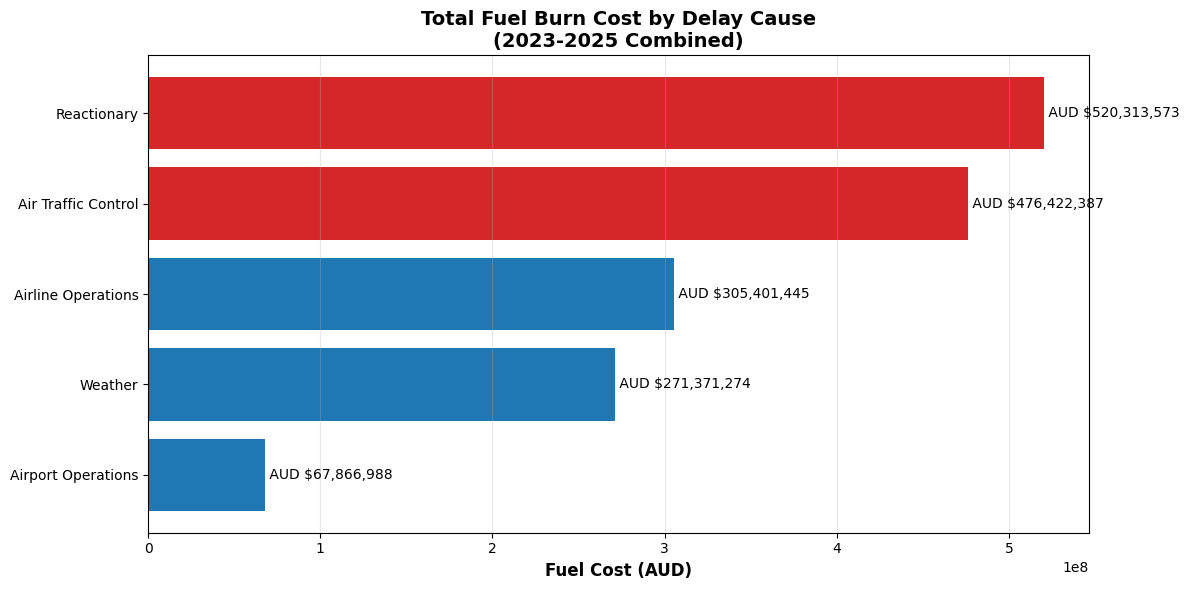

✅ Chart saved: 01_fuel_cost_by_delay_cause.png


In [37]:
# CELL 16: Chart 1 - Fuel Cost by Delay Cause
# ============================================================================
 
fig, ax = plt.subplots(figsize=(12, 6))
 
fuel_by_cause_plot = fuel_by_cause.sort_values('fuel_cost_aud', ascending=True)
colors = ['#d62728' if x > fuel_by_cause['fuel_cost_aud'].mean() else '#1f77b4' 
          for x in fuel_by_cause_plot['fuel_cost_aud']]
 
ax.barh(fuel_by_cause_plot['cause_name'], fuel_by_cause_plot['fuel_cost_aud'], color=colors)
ax.set_xlabel('Fuel Cost (AUD)', fontsize=12, fontweight='bold')
ax.set_title('Total Fuel Burn Cost by Delay Cause\n(2023-2025 Combined)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
 
# Add value labels
for i, v in enumerate(fuel_by_cause_plot['fuel_cost_aud']):
    ax.text(v, i, f' AUD ${v:,.0f}', va='center', fontsize=10)
 
plt.tight_layout()
plt.savefig('01_fuel_cost_by_delay_cause.png', dpi=300, bbox_inches='tight')
plt.show()
 
print("✅ Chart saved: 01_fuel_cost_by_delay_cause.png")

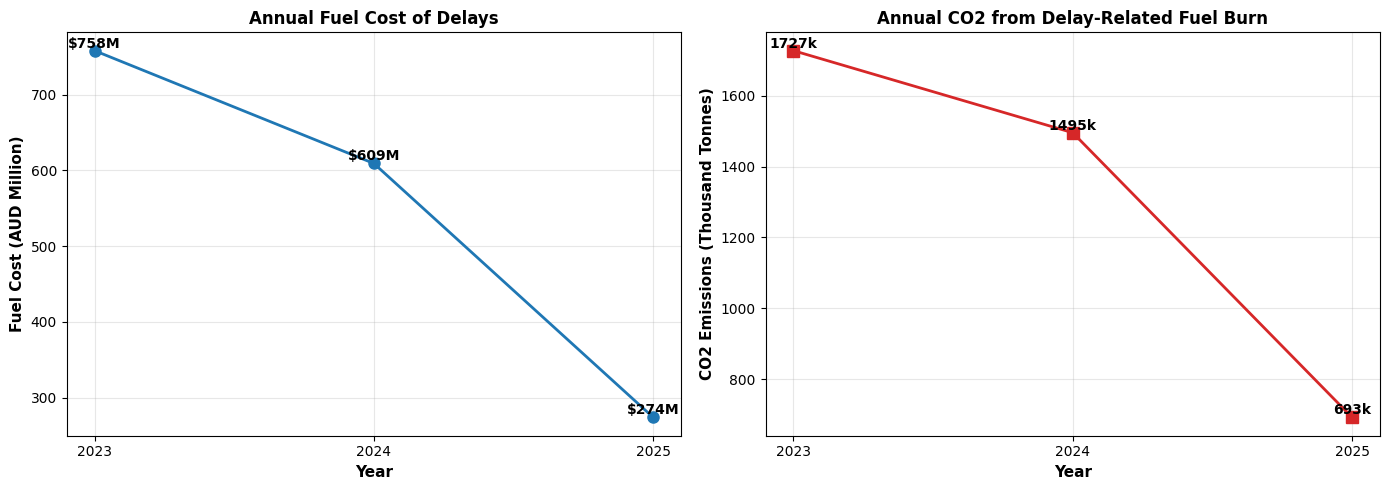

✅ Chart saved: 02_annual_fuel_cost_and_co2_trend.png


In [38]:
# CELL 17: Chart 2 - Annual Fuel Cost and CO2 Trend
# ============================================================================
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
# Fuel cost trend
ax1.plot(fuel_by_year['year'], fuel_by_year['fuel_cost_aud']/1e6, marker='o', linewidth=2, markersize=8, color='#1f77b4')
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Fuel Cost (AUD Million)', fontsize=11, fontweight='bold')
ax1.set_title('Annual Fuel Cost of Delays', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(fuel_by_year['year'])
 
# Add value labels
for x, y in zip(fuel_by_year['year'], fuel_by_year['fuel_cost_aud']/1e6):
    ax1.text(x, y, f'${y:.0f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
 
# CO2 emissions trend
ax2.plot(fuel_by_year['year'], fuel_by_year['co2_tonnes']/1e3, marker='s', linewidth=2, markersize=8, color='#d62728')
ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('CO2 Emissions (Thousand Tonnes)', fontsize=11, fontweight='bold')
ax2.set_title('Annual CO2 from Delay-Related Fuel Burn', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(fuel_by_year['year'])
 
# Add value labels
for x, y in zip(fuel_by_year['year'], fuel_by_year['co2_tonnes']/1e3):
    ax2.text(x, y, f'{y:.0f}k', ha='center', va='bottom', fontsize=10, fontweight='bold')
 
plt.tight_layout()
plt.savefig('02_annual_fuel_cost_and_co2_trend.png', dpi=300, bbox_inches='tight')
plt.show()
 
print("✅ Chart saved: 02_annual_fuel_cost_and_co2_trend.png")

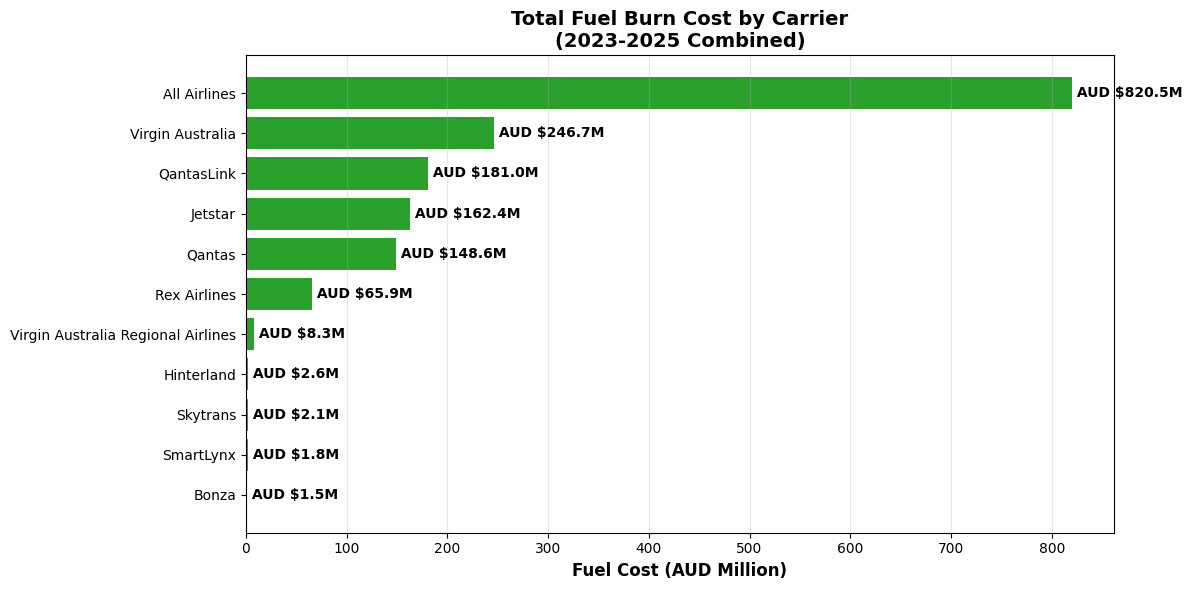

✅ Chart saved: 03_fuel_cost_by_carrier.png


In [39]:
# CELL 18: Chart 3 - Fuel Cost by Carrier
# ============================================================================
 
fig, ax = plt.subplots(figsize=(12, 6))
 
fuel_by_carrier_plot = fuel_by_carrier.sort_values('fuel_cost_aud', ascending=True)
ax.barh(fuel_by_carrier_plot['airline'], fuel_by_carrier_plot['fuel_cost_aud']/1e6, color='#2ca02c')
ax.set_xlabel('Fuel Cost (AUD Million)', fontsize=12, fontweight='bold')
ax.set_title('Total Fuel Burn Cost by Carrier\n(2023-2025 Combined)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
 
# Add value labels
for i, v in enumerate(fuel_by_carrier_plot['fuel_cost_aud']/1e6):
    ax.text(v, i, f' AUD ${v:.1f}M', va='center', fontsize=10, fontweight='bold')
 
plt.tight_layout()
plt.savefig('03_fuel_cost_by_carrier.png', dpi=300, bbox_inches='tight')
plt.show()
 
print("✅ Chart saved: 03_fuel_cost_by_carrier.png")

In [40]:
# CELL 19: Export Results to CSV
# ============================================================================
 
# Create output directory
import os
os.makedirs('processed_data', exist_ok=True)
 
# Export key datasets
analysis_by_cause.to_csv('processed_data/fuel_burn_by_delay_cause.csv', index=False)
fuel_by_cause.to_csv('processed_data/fuel_cost_summary_by_cause.csv', index=False)
fuel_by_year.to_csv('processed_data/fuel_cost_annual_trend.csv', index=False)
fuel_by_carrier.to_csv('processed_data/fuel_cost_by_carrier.csv', index=False)
 
print("✅ All processed data exported to 'processed_data/' directory:")
print("   - fuel_burn_by_delay_cause.csv")
print("   - fuel_cost_summary_by_cause.csv")
print("   - fuel_cost_annual_trend.csv")
print("   - fuel_cost_by_carrier.csv")
 
print("\n✅ All charts saved:")
print("   - 01_fuel_cost_by_delay_cause.png")
print("   - 02_annual_fuel_cost_and_co2_trend.png")
print("   - 03_fuel_cost_by_carrier.png")

✅ All processed data exported to 'processed_data/' directory:
   - fuel_burn_by_delay_cause.csv
   - fuel_cost_summary_by_cause.csv
   - fuel_cost_annual_trend.csv
   - fuel_cost_by_carrier.csv

✅ All charts saved:
   - 01_fuel_cost_by_delay_cause.png
   - 02_annual_fuel_cost_and_co2_trend.png
   - 03_fuel_cost_by_carrier.png


In [41]:
# CELL 20: Summary
# ============================================================================
 
print("\n" + "="*100)
print("FUEL BURN IMPACT OF FLIGHT DELAYS — KEY FINDINGS SUMMARY")
print("="*100)
 
print(f"""
1. TOTAL IMPACT (2023-2025)
   • Fuel burned due to delays: {analysis_by_cause['fuel_burn_litres'].sum():,.0f} litres
   • Cost of delay-related fuel: AUD ${analysis_by_cause['fuel_cost_aud'].sum():,.0f}
   • CO2 emitted: {analysis_by_cause['co2_tonnes'].sum():,.0f} tonnes
 
2. ANNUAL BASELINE
   • Average annual fuel cost: AUD ${fuel_by_year['fuel_cost_aud'].mean():,.0f}
   • Average annual fuel volume: {fuel_by_year['fuel_burn_litres'].mean():,.0f} litres
   • Average annual CO2: {fuel_by_year['co2_tonnes'].mean():,.0f} tonnes
 
3. HIGHEST IMPACT CAUSES (Top 3)
""")
 
for i, row in fuel_by_cause.head(3).iterrows():
    pct = (row['fuel_cost_aud']/fuel_by_cause['fuel_cost_aud'].sum()*100)
    print(f"   {row['cause_name']:<25} AUD ${row['fuel_cost_aud']:>15,.0f}  ({pct:>5.1f}%)")
 
print(f"""
4. CARRIER PERFORMANCE
   Highest cost carrier: {fuel_by_carrier.iloc[0]['airline']:<20} AUD ${fuel_by_carrier.iloc[0]['fuel_cost_aud']:,.0f}
   Lowest cost carrier:  {fuel_by_carrier.iloc[-1]['airline']:<20} AUD ${fuel_by_carrier.iloc[-1]['fuel_cost_aud']:,.0f}
 
5. OPERATIONAL EFFICIENCY SCENARIOS
   • 5% delay reduction = AUD ${fuel_by_year['fuel_cost_aud'].mean() * 0.05:,.0f}/year saving
   • 10% delay reduction = AUD ${fuel_by_year['fuel_cost_aud'].mean() * 0.10:,.0f}/year saving
   • 25% delay reduction (OneSKY) = AUD ${fuel_by_year['fuel_cost_aud'].mean() * 0.25:,.0f}/year saving
""")
 
print("="*100)
print("✅ Analysis complete!")
print("="*100)


FUEL BURN IMPACT OF FLIGHT DELAYS — KEY FINDINGS SUMMARY

1. TOTAL IMPACT (2023-2025)
   • Fuel burned due to delays: 1,548,500,561 litres
   • Cost of delay-related fuel: AUD $1,641,375,667
   • CO2 emitted: 3,914,609 tonnes

2. ANNUAL BASELINE
   • Average annual fuel cost: AUD $547,125,222
   • Average annual fuel volume: 516,166,854 litres
   • Average annual CO2: 1,304,870 tonnes

3. HIGHEST IMPACT CAUSES (Top 3)

   Reactionary               AUD $    520,313,573  ( 31.7%)
   Air Traffic Control       AUD $    476,422,387  ( 29.0%)
   Airline Operations        AUD $    305,401,445  ( 18.6%)

4. CARRIER PERFORMANCE
   Highest cost carrier: All Airlines         AUD $820,531,651
   Lowest cost carrier:  Bonza                AUD $1,507,086

5. OPERATIONAL EFFICIENCY SCENARIOS
   • 5% delay reduction = AUD $27,356,261/year saving
   • 10% delay reduction = AUD $54,712,522/year saving
   • 25% delay reduction (OneSKY) = AUD $136,781,306/year saving

✅ Analysis complete!
